#question_2

In [3]:
a = [i for i in range(1,11)]
b = a*6
for i,j in zip (a,b):
print (i, 'x 6', '= ', j)

IndentationError: expected an indented block after 'for' statement on line 3 (1667130628.py, line 4)

#this is not giving us the desired result.
#this code is giving us indentation error because we have not given the proper indentaion for the print function
#the first modification we need to make is giving the print function a proper indentation (4 spaces).

In [2]:
a = [i for i in range(1,11)]
b = a*6
for i,j in zip (a,b):
    print (i, 'x 6', '= ', j)

1 x 6 =  1
2 x 6 =  2
3 x 6 =  3
4 x 6 =  4
5 x 6 =  5
6 x 6 =  6
7 x 6 =  7
8 x 6 =  8
9 x 6 =  9
10 x 6 =  10


#second modification needed is the defination of b it is just repeating the list instead of multiplying each element to fix this problem changing the defination of b for multiplying each element by 6.

In [4]:
a = [i for i in range(1,11)]
b = [i*6 for i in a]
for i,j in zip (a,b):
    print (i, 'x 6', '= ', j)

1 x 6 =  6
2 x 6 =  12
3 x 6 =  18
4 x 6 =  24
5 x 6 =  30
6 x 6 =  36
7 x 6 =  42
8 x 6 =  48
9 x 6 =  54
10 x 6 =  60


#question_3

In [ ]:
import csv
import matplotlib.pyplot as plt

#reading file and calculating speed in km/h

In [10]:
import csv


def read_and_convert_speed():
    """Convert Doppler-shift data to vehicle speed in km/h."""

    speed_of_light_cm_s = 3e10
    cm_s_to_km_h = 0.036

    csv_path = (
        "/Users/ashutoshsrivastava/Documents/GitHub/"
        "ashutosh_srivastava_numerical_methods_2026/speedgundata.csv"
    )

    speed_data = {}

    with open(csv_path, "r", newline="") as file:
        reader = csv.DictReader(file)

        for row in reader:
            for road, doppler_shift in row.items():
                if doppler_shift == "":
                    continue

                doppler_shift = float(doppler_shift)

                # v = (Doppler shift × speed of light) / 2
                speed_cm_s = doppler_shift * speed_of_light_cm_s / 2
                speed_km_h = speed_cm_s * cm_s_to_km_h

                speed_data.setdefault(road, []).append(speed_km_h)

    return speed_data


# Display all calculated speeds
speed_data = read_and_convert_speed()

for road, speeds in speed_data.items():
    print(f"\n{road} speeds:")
    for speed in speeds:
        print(f"{speed:.2f} km/h")




Atal Setu speeds:
92.74 km/h
98.14 km/h
101.44 km/h
101.47 km/h
102.41 km/h
94.86 km/h
101.43 km/h
101.14 km/h
95.29 km/h
95.09 km/h
107.17 km/h
93.03 km/h
93.86 km/h
99.20 km/h
107.12 km/h
105.51 km/h
86.43 km/h
102.00 km/h
101.69 km/h
95.52 km/h
101.42 km/h
94.18 km/h
92.44 km/h
97.97 km/h
101.52 km/h
104.87 km/h
101.79 km/h
106.27 km/h
100.35 km/h
99.49 km/h
93.36 km/h
98.91 km/h
106.03 km/h
101.91 km/h
111.09 km/h
102.83 km/h
98.20 km/h
101.30 km/h
104.95 km/h
107.70 km/h
103.69 km/h
100.25 km/h
92.29 km/h
100.00 km/h
95.26 km/h
97.73 km/h
101.85 km/h
98.02 km/h
110.79 km/h
107.12 km/h
99.82 km/h
98.38 km/h
100.52 km/h
98.96 km/h
108.76 km/h
95.75 km/h
94.59 km/h
103.11 km/h
101.66 km/h
101.67 km/h
97.91 km/h
90.54 km/h
100.67 km/h
101.79 km/h
89.94 km/h
108.00 km/h
98.60 km/h
100.49 km/h
88.88 km/h
97.63 km/h
97.31 km/h
104.77 km/h
100.41 km/h
98.63 km/h
99.51 km/h
113.53 km/h
105.83 km/h
91.75 km/h
97.73 km/h
97.01 km/h
102.38 km/h
101.34 km/h
110.01 km/h
95.16 km/h
100.18 km/h


#plotting the histogram of the speed data

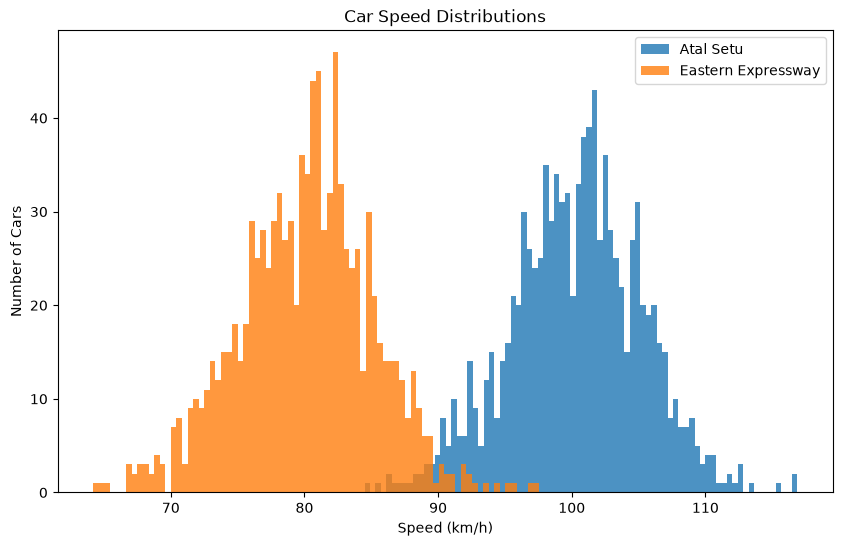

In [142]:
import matplotlib.pyplot as plt

def plot_histograms(speed_data):
    plt.figure(figsize=(10,6))
    
    for road, speeds in speed_data.items():
        plt.hist(speeds, bins=80, alpha=0.8, label=road,)
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Number of Cars")
    plt.title("Car Speed Distributions")
    plt.legend()
    plt.show()
plot_histograms(speed_data)

#fraction of cars which are speeding

In [42]:
def fraction_speeding(speed_data):
    limits = {"Atal Setu": 100, "Eastern Expressway": 80}
    fractions = {}
    
    for road, speeds in speed_data.items():
        limit = limits[road]
        threshold = limit * 1.05  # 5% grace
        
        speeding = sum(1 for v in speeds if v > threshold)
        fractions[road] = speeding / len(speeds)
    
    return fractions
fraction_speeding(speed_data)


{'Atal Setu': 0.169, 'Eastern Expressway': 0.209}

#plot of the fraction of cars speeding on each road

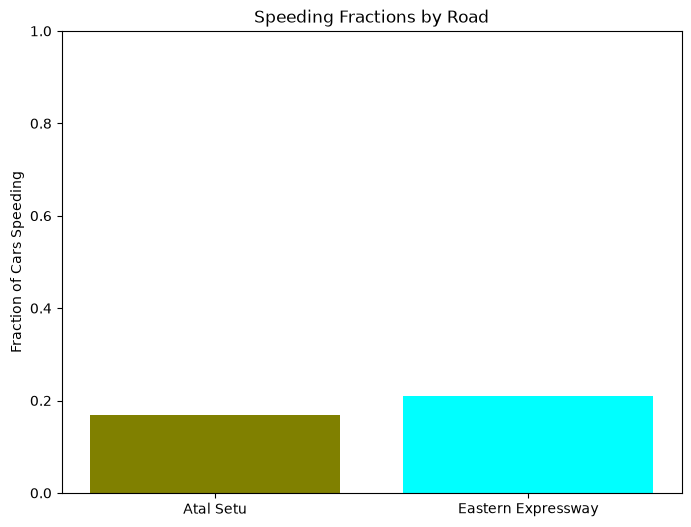

In [64]:
result = read_and_convert_speed()
fractions = fraction_speeding(result)
import matplotlib.pyplot as plt

def plot_speeding_fractions (fractions):
    roads = list(fractions.keys())
    values = [fractions[road] for road in roads]
    
    plt.figure(figsize=(8,6))
    plt.bar(roads, values, color=['olive','cyan'])
    
    plt.ylabel("Fraction of Cars Speeding")
    plt.title("Speeding Fractions by Road")
    plt.ylim(0,1)  # fractions are between 0 and 1
    plt.show()
plot_speeding_fractions(fractions)

#question_4
simulation definition for the ant walking on the 2D surface.

In [128]:
import numpy as np

def ant_walk(food_pos, start_pos=[0,0], m=0.1, N=1000, seed=None):
    """
    Simulates an ant moving towards food in 2D space.
    
    """
    if seed is not None:
        np.random.seed(seed)
    
    ant_pos = np.array(start_pos, dtype=float)
    food_pos = np.array(food_pos, dtype=float)
    path = [tuple(ant_pos)]
    
    for step in range(N):
        # Distance vector
        d_vec = food_pos - ant_pos
        d = np.linalg.norm(d_vec)
        
        if d < 1:  # Ant reaches food
            path.append(tuple(food_pos))
            return path, True, step+1
        
        # True angle to food
        phi = np.arctan2(d_vec[1], d_vec[0])
        
        # Guess angle with normal noise
        sigma = m * d
        guess_angle = np.random.normal(phi, sigma)
        
        # Step of unit length
        ant_pos += np.array([np.cos(guess_angle), np.sin(guess_angle)])
        path.append(tuple(ant_pos))
    
    return path, False, N

#plot of the random path of the ant.

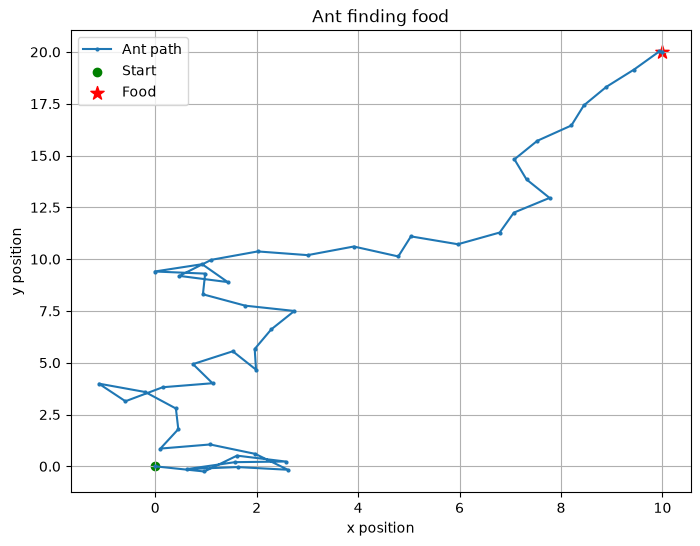

In [145]:
import matplotlib.pyplot as plt

# Example run
path, success, steps = ant_walk(food_pos=[10,20], start_pos=[0,0], m=0.1, N=100, seed=40)

x, y = zip(*path)
plt.figure(figsize=(8,6))
plt.plot(x, y, '-o', markersize=2, label="Ant path")
plt.scatter([0], [0], c='green', marker='o', label="Start")
plt.scatter([10], [20], c='red', marker='*', s=100, label="Food")
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Ant finding food")
plt.legend()
plt.grid(True)
plt.show()


#data of the ants 100 ants how many will reach the food, their mean and their standard deviation.

In [149]:
steps_list = []
unsuccessful = 0

for i in range(100):
    _, success, steps = ant_walk(food_pos=[10,20], start_pos=[0,0], m=0.1, N=1000)
    if success:
        steps_list.append(steps)
    else:
        unsuccessful += 1

mean_steps = np.mean(steps_list)
std_steps = np.std(steps_list)

print("Successful ants:", len(steps_list))
print("Unsuccessful ants:", unsuccessful)
print("Mean steps:", mean_steps)
print("Std deviation:", std_steps)


Successful ants: 99
Unsuccessful ants: 1
Mean steps: 105.27272727272727
Std deviation: 106.15995347043447


out of that 100 ants only 1 was unsuccessful.


#mean and standard deviation graph

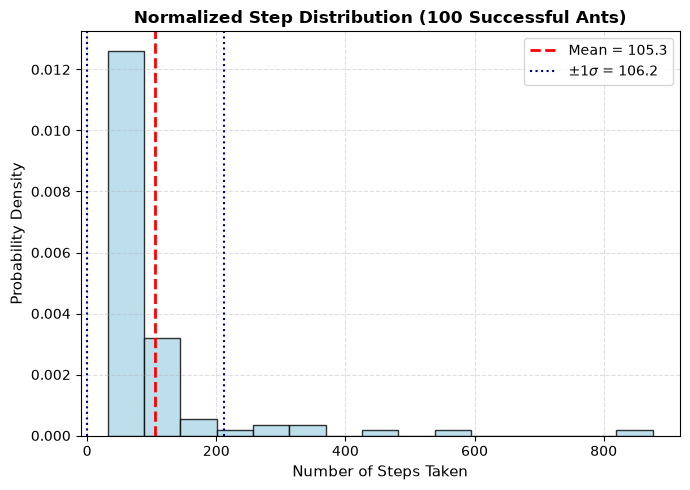

In [150]:
plt.figure(figsize=(7, 5), dpi=100)
count, bins, _ = plt.hist(
    successful_steps,
    bins=15,
    density=True,
    color="lightblue",
    edgecolor="black",
    alpha=0.8,
)

plt.axvline(
    mean_steps,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_steps:.1f}",
)
plt.axvline(
    mean_steps - std_steps,
    color="darkblue",
    linestyle=":",
    linewidth=1.5,
    label=f"$\pm 1\sigma$ = {std_steps:.1f}",
)
plt.axvline(mean_steps + std_steps, color="darkblue", linestyle=":", linewidth=1.5)

plt.title(
    "Normalized Step Distribution (100 Successful Ants)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Steps Taken", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


#efficiency of ants with respect to distance.

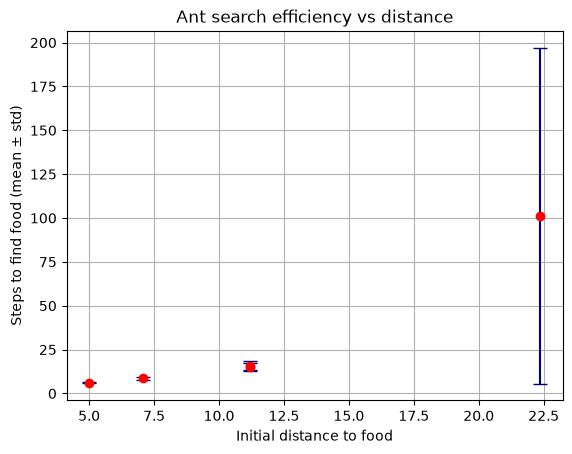

In [132]:

food_positions = [[0,5], [5,5], [10,5], [5,10], [10,20]]
start_pos = [0,0]
m = 0.1
N = 1000

mean_steps_list = []
std_steps_list = []
distances = []

for food in food_positions:
    steps_list = []
    unsuccessful = 0
    
    for i in range(100):
        _, success, steps = ant_walk(food_pos=food, start_pos=start_pos, m=m, N=N)
        if success:
            steps_list.append(steps)
        else:
            unsuccessful += 1
    
    d = np.linalg.norm(np.array(food) - np.array(start_pos))
    distances.append(d)
    
    mean_steps_list.append(np.mean(steps_list))
    std_steps_list.append(np.std(steps_list))
# Scatter + errorbar plot
plt.errorbar(distances, mean_steps_list, yerr=std_steps_list, fmt='o',color="red",ecolor="navy", capsize=5)
plt.xlabel("Initial distance to food")
plt.ylabel("Steps to find food (mean ± std)")
plt.title("Ant search efficiency vs distance")
plt.grid(True)
plt.show()


#7(part 7) Yes, the result of the efficiency of the ants makes sence because for the positions [5,10] and [10,5] the steps to find the food is exactly same and this is what we expected for the same distance the standard deviation should come up same .
And as we can see from the above plot if food is located far away the standard deviation of the steps to find the food is large.